# Model Project

Import and set magics:

In [211]:
import numpy as np
import matplotlib.pyplot as plt

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import modelproject

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


> Part 1: A consumer with two nests

> 1.1: The problem in nested budget shares

In [212]:
# Setup
from scipy import optimize

def nested_budget_utility(shares, p1, p2, p3, I, alpha, beta, sigma_A, sigma_B):
    """
    Calculates utility based on the nested budget shares.
    """
    s1, w = shares

    s2 = (1.0 - s1) * w
    s3 = (1.0 - s1) * (1.0 - w)

    # Use above to calculate amounts of each product/good
    x1 = (s1 * I) / p1
    x2 = (s2 * I) / p2
    x3 = (s3 * I) / p3

    # Using the elasticities to calculate the rho-exponents
    rho_A = 1.0 - (1.0 / sigma_A)
    rho_B = 1.0 - (1.0 / sigma_B)

    term_B = beta * (x2 ** rho_B) + (1.0 - beta) * (x3 ** rho_B)
    xB = term_B ** (1.0 / rho_B)
    term_A = alpha * (x1 ** rho_A) + (1.0 - alpha) * (xB ** rho_A)
    u = term_A ** (1.0 / rho_A)

    return -u # Negative to prepare for maximising with SciPy

def solve_consumer_problem(p1, p2, p3, I, alpha, beta, sigma_A, sigma_B, method='L-BFGS-B'):
    # Initial guess
    init_guess = [0.5, 0.5]

    # Bounds
    eps = 1e-7
    bounds = [(eps, 1.0 - eps), (eps, 1.0 - eps)]

    # Optimize using L-BFGS-B
    result = optimize.minimize(nested_budget_utility, init_guess, 
                               args=(p1, p2, p3, I, alpha, beta, sigma_A, sigma_B),
                               method=method, bounds=bounds)

    if result.success:
        opt_s1, opt_w = result.x
        opt_s2 = (1.0 - opt_s1) * opt_w
        opt_s3 = (1.0 - opt_s1) * (1.0 - opt_w)

        return{
            'success': True,
            'optimal_s1': opt_s1,
            'optimal_w': opt_w,
            'budget_shares': [opt_s1, opt_s2, opt_s3],
            'max_utility': -result.fun,
            'quantities': [opt_s1 * I / p1, opt_s2 * I / p2, opt_s3 * I / p3]
        }
    else:
        return {'success': False, 'message': result.message}

> 1.2: Calibration and 1.3: How to tell if the answer is right

In [213]:
# Setup
from types import SimpleNamespace

class ConsumerClass:
    """
    A consumer with nested CES preferences over three goods
    """
    def __init__(self, par=None):
        self.setup()

        if not par is None:
            for k, v in par.items():
                self.par.__dict__[k] = v

    def setup(self):
        par = self.par = SimpleNamespace()
        self.sol = SimpleNamespace()

        par.alpha = 0.6
        par.beta = 0.5

        par.sigma_A = 0.8
        par.sigma_B = 0.4

        par.p1 = 1.0
        par.p2 = 1.0
        par.p3 = 1.5
        par.I = 10.0

        par.s_min = 1e-12

    def __str__(self):
        par = self.par
        lines = ['ConsumerClass']
        lines.append(f'alpha = {par.alpha:.2f}, beta = {par.beta:.2f}')
        lines.append(f'sigma_A = {par.sigma_A:.2f}, sigma_B = {par.sigma_B:.2f}')
        lines.append(f'p1 = {par.p1:.2f}, p2 = {par.p2:.2f}, p3 = {par.p3:.2f}')
        lines.append(f'I = {par.I:.2f}')
        return '\n'.join(lines)

    def utility(self, shares):
        """
        Using previously established utility definition
        """
        p = self.par
        return nested_budget_utility(shares, p.p1, p.p2, p.p3, p.I, p.alpha, p.beta, p.sigma_A, p.sigma_B)

    def solve(self, method='L-BFGS-B'):
        """
        Using previously established solve definition
        """
        p = self.par
        sol = self.sol

        res = solve_consumer_problem(p.p1, p.p2, p.p3, p.I, p.alpha, p.beta, p.sigma_A, p.sigma_B, method=method)
        sol.success = res['success']
        if sol.success:
            sol.s1 = float(res['optimal_s1'])
            sol.w = float(res['optimal_w'])
            sol.s2 = float(res['budget_shares'][1])
            sol.s3 = float(res['budget_shares'][2])
            sol.x1 = float(res['quantities'][0])
            sol.x2 = float(res['quantities'][1])
            sol.x3 = float(res['quantities'][2])
            sol.u = float(res['max_utility'])

if __name__ == '__main__': # part 1.3
    calibrations = [('Complements', 0.4), ('Substitutes', 3.0)]

    for name, sigma_B in calibrations:
        print(f'Controlling for {name.upper()} (sigma_B = {sigma_B})...')

        model = ConsumerClass(par={'sigma_B': sigma_B})

        # Method 1: L-BFGS-B
        model.solve()
        s1, s2, s3 = model.sol.s1, model.sol.s2, model.sol.s3
        x1, x2, x3 = model.sol.x1, model.sol.x2, model.sol.x3
        u_lbfgsb = model.sol.u

        # First control...
        shares_in_bounds = all(0.0 < s < 1.0 for s in [s1, s2, s3])
        shares_sum_to_one = np.isclose(s1 + s2 + s3, 1.0, atol=1e-8)
        quantities_positiveor0 = all(x >= 0.0 for x in [x1, x2, x3])

        print('Is solution possible?')
        print(f' - Budget shares [1,0]: {shares_in_bounds}')
        print(f' - Budget shares sum to 1.0: {shares_sum_to_one}')
        print(f' - Amounts of products is greater than or equal to 0: {quantities_positiveor0}')

        # Method 2: SLSQP
        model.solve(method='SLSQP')
        u_slsqp = model.sol.u
        methods_agree = np.isclose(u_lbfgsb, u_slsqp, atol=1e-6)

        print('Do the two methods agree?')
        print(f' - Methods yield same maxium utility: {methods_agree}')
        print(f' - L-BFGS-B u_max: {u_lbfgsb:.4f}')
        print(f' - SLSQP u_max: {u_slsqp:.4f}')

Controlling for COMPLEMENTS (sigma_B = 0.4)...
Is solution possible?
 - Budget shares [1,0]: True
 - Budget shares sum to 1.0: True
 - Amounts of products is greater than or equal to 0: True
Do the two methods agree?
 - Methods yield same maxium utility: True
 - L-BFGS-B u_max: 3.4017
 - SLSQP u_max: 3.4017
Controlling for SUBSTITUTES (sigma_B = 3.0)...
Is solution possible?
 - Budget shares [1,0]: True
 - Budget shares sum to 1.0: True
 - Amounts of products is greater than or equal to 0: True
Do the two methods agree?
 - Methods yield same maxium utility: True
 - L-BFGS-B u_max: 3.4851
 - SLSQP u_max: 3.4851


In [214]:
# Solving with differing sigma_B

if __name__ == '__main__':
    model_comp = ConsumerClass(par={'sigma_B': 0.4})
    model_comp.solve()

    model_sub = ConsumerClass(par={'sigma_B': 3.0})
    model_sub.solve()

    print('Complements; sigma_B = 0.4 < 1')
    print(f"Optimal nested shares (s1, w): ({model_comp.sol.s1:.2f}, {model_comp.sol.w:.2f})")
    print(f"Budget shares (s1, s2, s3): {[round(model_comp.sol.s1, 2), round(model_comp.sol.s2, 2), round(model_comp.sol.s3, 2)]}")
    print(f"Optimal consumption amounts (x1, x2, x3): {[round(model_comp.sol.x1, 2), round(model_comp.sol.x2, 2), round(model_comp.sol.x3, 2)]}")
    print(f"Maximum utility: {model_comp.sol.u:.2f}")
    print('')
    print('Substitutes; sigma_B = 3 > 1')
    print(f"Optimal nested shares (s1, w): ({model_sub.sol.s1:.2f}, {model_sub.sol.w:.2f})")
    print(f"Budget shares (s1, s2, s3): {[round(model_sub.sol.s1, 2), round(model_sub.sol.s2, 2), round(model_sub.sol.s3, 2)]}")
    print(f"Optimal consumption amounts (x1, x2, x3): {[round(model_sub.sol.x1, 2), round(model_sub.sol.x2, 2), round(model_sub.sol.x3, 2)]}")
    print(f"Maximum utility: {model_sub.sol.u:.2f}")

Complements; sigma_B = 0.4 < 1
Optimal nested shares (s1, w): (0.54, 0.44)
Budget shares (s1, s2, s3): [0.54, 0.2, 0.26]
Optimal consumption amounts (x1, x2, x3): [5.36, 2.04, 1.74]
Maximum utility: 3.40

Substitutes; sigma_B = 3 > 1
Optimal nested shares (s1, w): (0.54, 0.69)
Budget shares (s1, s2, s3): [0.54, 0.32, 0.14]
Optimal consumption amounts (x1, x2, x3): [5.38, 3.2, 0.95]
Maximum utility: 3.49


> Part 2: Solving the model numerically

> 2.1: A two-dimensional grid search

In [215]:
# Setup
def grid_search(p1, p2, p3, I, alpha, beta, sigma_A, sigma_B, N=1000):
    s_min = 1e-12

    # Vectors
    s1_vec = np.linspace(s_min, 1.0 - s_min, N)
    w_vec = np.linspace(s_min, 1.0 - s_min, N)

    # Grid
    s1_grid, w_grid = np.meshgrid(s1_vec, w_vec, indexing='ij')

    s2_grid = (1.0 - s1_grid) * w_grid
    s3_grid = (1.0 - s1_grid) * (1.0 - w_grid)

    x1 = (s1_grid * I) / p1
    x2 = (s2_grid * I) / p2
    x3 = (s3_grid * I) / p3

    rho_A = 1.0 - (1.0 / sigma_A)
    rho_B = 1.0 - (1.0 / sigma_B)

    term_B = beta * (x2 ** rho_B) + (1.0 - beta) * (x3 ** rho_B)
    xB = term_B ** (1.0 / rho_B)

    term_A = alpha * (x1 ** rho_A) + (1.0 - alpha) * (xB ** rho_A)
    u_grid = term_A ** (1.0 / rho_A)

    # Finding the best combination
    flat_max_index = np.argmax(u_grid)
    index_s1, index_w = np.unravel_index(flat_max_index, u_grid.shape)

    opt_s1 = float(s1_grid[index_s1, index_w])
    opt_w = float(w_grid[index_s1, index_w])

    opt_s2 = (1.0 - opt_s1) * opt_w
    opt_s3 = (1.0 - opt_s1) * (1.0 - opt_w)
    max_u = float(u_grid[index_s1, index_w])

    return{
        's1': opt_s1,
        'w': opt_w,
        'budget_shares': [opt_s1, opt_s2, opt_s3],
        'utility': max_u,
        's1_grid': s1_grid,
        'w_grid': w_grid,
        'u_grid': u_grid
    }

# Conducting grid search
if __name__ == '__main__':
    # Parameters
    I, p1, p2, p3 = 10.0, 1.0, 1.0, 1.5
    alpha, beta, sigma_A = 0.6, 0.5, 0.8

    calibrations = [('Complements', 0.4), ('Substitutes', 3.0)]

    for name, sigma_B in calibrations:
        print(f'Grid search result: {name.upper()} (sigma_B = {sigma_B})...')

        res = grid_search(p1, p2, p3, I, alpha, beta, sigma_A, sigma_B, N=200)

        s1, s2, s3 = res['budget_shares']
        x1_opt = (s1 * I) / p1
        x2_opt = (s2 * I) / p2
        x3_opt = (s3 * I) / p3

        print(f"Optimal nested shares (s1, w): ({res['s1']:.2f}, {res['w']:.2f})")
        print(f"Budget shares (s1, s2, s3): {[round(s, 2) for s in res['budget_shares']]}")
        print(f"Optimal consumption amounts (x1, x2, x3): {[round(model_comp.sol.x1, 2), round(model_comp.sol.x2, 2), round(model_comp.sol.x3, 2)]}")
        print(f"Maximum utility: {res['utility']:.2f}")
        print('')

        print('Grid size N | Evaluations | Optimal s1 | Optimal w | Utility')
        print('-'*90)
        for N_test in [50, 100, 500, 1000]:
            res_test = grid_search(p1, p2, p3, I, alpha, beta, sigma_A, sigma_B, N=N_test)

            print(f"{N_test:<11} | {N_test**2:<11,} | {res_test['s1']:<10.4f} | {res_test['w']:<9.4f} | {res_test['utility']:<9.4f}")

        print('')

Grid search result: COMPLEMENTS (sigma_B = 0.4)...
Optimal nested shares (s1, w): (0.54, 0.44)
Budget shares (s1, s2, s3): [0.54, 0.2, 0.26]
Optimal consumption amounts (x1, x2, x3): [5.36, 2.04, 1.74]
Maximum utility: 3.40

Grid size N | Evaluations | Optimal s1 | Optimal w | Utility
------------------------------------------------------------------------------------------
50          | 2,500       | 0.5306     | 0.4490    | 3.4007   
100         | 10,000      | 0.5354     | 0.4444    | 3.4015   
500         | 250,000     | 0.5351     | 0.4389    | 3.4017   
1000        | 1,000,000   | 0.5355     | 0.4394    | 3.4017   

Grid search result: SUBSTITUTES (sigma_B = 3.0)...
Optimal nested shares (s1, w): (0.54, 0.69)
Budget shares (s1, s2, s3): [0.54, 0.32, 0.14]
Optimal consumption amounts (x1, x2, x3): [5.36, 2.04, 1.74]
Maximum utility: 3.49

Grid size N | Evaluations | Optimal s1 | Optimal w | Utility
-----------------------------------------------------------------------------------

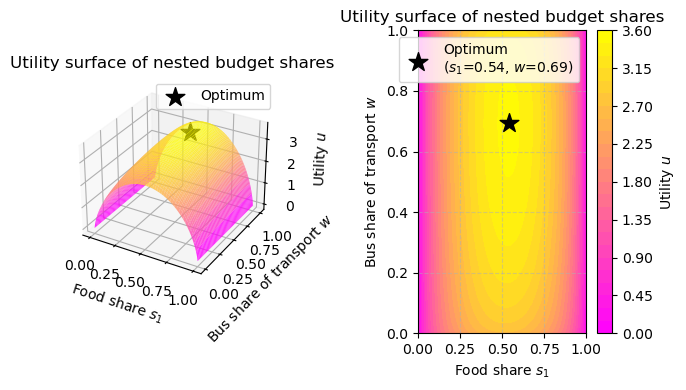

In [216]:
# Plotting in 3D
fig_gridsearch = plt.figure(figsize=(7, 4))
ax_gridsearch = fig_gridsearch.add_subplot(1, 2, 1, projection='3d')

surface_gs = ax_gridsearch.plot_surface(res['s1_grid'], res['w_grid'], res['u_grid'], cmap='spring', edgecolor='none', alpha=0.8)

ax_gridsearch.scatter(res['s1'], res['w'], res['utility'], color='black', marker='*', s=200, label='Optimum', zorder=5)

ax_gridsearch.set_title('Utility surface of nested budget shares')
ax_gridsearch.set_xlabel('Food share $s_1$')
ax_gridsearch.set_ylabel('Bus share of transport $w$')
ax_gridsearch.set_zlabel('Utility $u$')
ax_gridsearch.legend()

ax_gridsearch2 = fig_gridsearch.add_subplot(1, 2, 2)

contour = ax_gridsearch2.contourf(res['s1_grid'], res['w_grid'], res['u_grid'], levels=25, cmap='spring')
fig_gridsearch.colorbar(contour, ax=ax_gridsearch2, label='Utility $u$')
ax_gridsearch2.scatter(res['s1'], res['w'], color='black', marker='*', s=200, edgecolor='black', 
                       label=f'Optimum\n($s_1$={res['s1']:.2f}, $w$={res['w']:.2f})', zorder=5)

ax_gridsearch2.set_title('Utility surface of nested budget shares')
ax_gridsearch2.set_xlabel('Food share $s_1$')
ax_gridsearch2.set_ylabel('Bus share of transport $w$')
ax_gridsearch2.grid(True, linestyle='--', alpha=0.5)
ax_gridsearch2.legend()

plt.subplots_adjust(wspace=5)

plt.tight_layout()
plt.show()

In [217]:
# Comparison of slopes and optimization
def optimizer_test(p1, p2, p3, I, alpha, beta, sigma_A, sigma_B):
    init_guess = [0.5, 0.5]
    eps = 1e-7
    bounds = [(eps, 1.0 - eps), (eps, 1.0 - eps)]

    result = optimize.minimize(nested_budget_utility, init_guess, 
                               args=(p1, p2, p3, I, alpha, beta, sigma_A, sigma_B),
                               method='L-BFGS-B', bounds=bounds)
    return result

if __name__ == '__main__':
    # Parameters
    I, p1, p2, p3 = 10.0, 1.0, 1.0, 1.5
    alpha, beta, sigma_A = 0.6, 0.5, 0.8

    calibrations = [('Complements', 0.4), ('Substitutes', 3.0)]

    for name, sigma_B in calibrations:
        res = optimizer_test(p1, p2, p3, I, alpha, beta, sigma_A, sigma_B)
        
        opt_s1, opt_w = res.x
        
        print(f"Calibration: {name.upper()} sigma_B = {sigma_B}")
        print(f"  - Optimal solution point (s1, w):           ({opt_s1:.4f}, {opt_w:.4f})")
        print(f"  - Total iterations:                         {res.nit}")
        print(f"  - Total evaluations of utility:             {res.nfev}")
        print(f"  - Optimizer's success:                      {res.success}")
        
        h = 1e-5
        u_opt = -res.fun
        u_moved = -nested_budget_utility([opt_s1, opt_w - h], p1, p2, p3, I, alpha, beta, sigma_A, sigma_B)
        slope_w = (u_opt - u_moved) / h
        print(f"  - Slope along w-axis proximity to top/optimum:  {abs(slope_w):.4f}")
        print('')

Calibration: COMPLEMENTS sigma_B = 0.4
  - Optimal solution point (s1, w):           (0.5356, 0.4395)
  - Total iterations:                         4
  - Total evaluations of utility:             18
  - Optimizer's success:                      True
  - Slope along w-axis proximity to top/optimum:  0.0001

Calibration: SUBSTITUTES sigma_B = 3.0
  - Optimal solution point (s1, w):           (0.5382, 0.6923)
  - Total iterations:                         6
  - Total evaluations of utility:             27
  - Optimizer's success:                      True
  - Slope along w-axis proximity to top/optimum:  0.0000



> 2.2: L-BFGS-B

In [234]:
# Setup
import time

def solve(p1, p2, p3, I, alpha, beta, sigma_A, sigma_B, path_list=None):

    def prep_minimize(shares):
        s1, w = shares
        s2 = (1.0 - s1) * w
        s3 = (.0 - s1) * (1.0 - w)

        x1 = (s1 * I) / p1
        x2 = (s2 * I) / p2
        x3 = (s3 * I) / p3

        x1 = np.clip(x1, 1e-7, None)
        x2 = np.clip(x2, 1e-7, None)
        x3 = np.clip(x3, 1e-7, None)

        rho_A = 1.0 - (1.0 / sigma_A)
        rho_B = 1.0 - (1.0 / sigma_B)

        term_B = beta * (x2 ** rho_B) + (1.0 - beta) * (x3 ** rho_B)
        term_B = np.clip(term_B, 1e-7, None)

        xB = term_B ** (1.0 / rho_B)
        xB = np.clip(xB, 1e-7, None)

        term_A = alpha * (x1 ** rho_A) + (1.0 - alpha) * (xB ** rho_A)
        term_A = np.clip(term_A, 1e-7, None)

        u = term_A ** (1.0 / rho_A)

        return -u

    s1_0 = 0.5 # Initial guess
    w_0 = p2 / (p2 + p3)
    s0 = [s1_0, w_0]

    path_list = []

    if path_list is not None:
        path_list.append(np.array(s0).copy())

    eps = 1e-5
    bounds = ((eps, 1.0 - eps), (eps, 1.0 - eps))

    callback = (lambda sk: path_list.append(sk.copy())) if path_list is not None else None

    result = optimize.minimize(prep_minimize, s0, method='L-BFGS-B', bounds=bounds)

    if not result.success:
        result = optimize.minimize(prep_minimize, s0, method='SLSQP', bounds=bounds)

    if result.success:
        opt_s1 = float(result.x[0]) 
        opt_w = float(result.x[1])
        opt_s2 = (1.0 - opt_s1) * opt_w
        opt_s3 = (1.0 - opt_s1) * (1.0 - opt_w)

        return {
            'success': True,
            's1': opt_s1,
            'w': opt_w,
            'budget_shares': [opt_s1, opt_s2, opt_s3],
            'utility': -result.fun,
            'nfev': result.nfev
        }

    return {'success': False, 'message': result.message}

if __name__ == '__main__':
    I, p1, p2, p3 = 10.0, 1.0, 1.0, 1.5
    alpha, beta, sigma_A = 0.6, 0.5, 0.8
    calibrations = [('Complements', 0.4), ('Substitutes', 3.0)]

    for name, sigma_B in calibrations:
        print(f'Comparison of calibrations: {name.upper()}, sigma_B = {sigma_B}')

        # Assessment of L-BFGS-B solver
        t0_sol = time.perf_counter()
        res_sol = solve(p1, p2, p3, I, alpha, beta, sigma_A, sigma_B)
        t1_sol = time.perf_counter()
        time_sol = t1_sol - t0_sol

        # Assessment of grid search
        t0_grid = time.perf_counter()
        res_grid = grid_search(p1, p2, p3, I, alpha, beta, sigma_A, sigma_B, N=1000)
        t1_grid = time.perf_counter()
        time_grid = t1_grid - t0_grid

        if not res_sol['success']:
            print(f'Optimization failure for {name}: {res_sol.get('message')}')
            continue

        print(f"{'Parameter':<25} | {'L-BFGS-B solver':<25} | {'Grid Search':<25}")
        print("-" * 100)
        print(f"{'Optimal s1':<25} | {res_sol['s1']:<25.6f} | {res_grid['s1']:<25.6f}")
        print(f"{'Optimal w':<25} | {res_sol['w']:<25.6f} | {res_grid['w']:<25.6f}")
        print(f"{'Budget shares [s1,s2,s3]':<25} | {[round(s,4) for s in res_sol['budget_shares']]}         | {[round(s,4) for s in res_grid['budget_shares']]}")
        print(f"{'u_max':<25} | {res_sol['utility']:<25.6f} | {res_grid['utility']:<25.6f}")
        print(f"{'Total evaluations':<25} | {res_sol['nfev']:<25,} | {1000**2:<25,}")
        print(f"{'Runtime':<25} | {time_sol:<25.6f} | {time_grid:<25.6f}")

        agree = np.isclose(res_sol['utility'], res_grid['utility'], atol=1e-4)
        print(f'\n> Methods agree: {agree}')
        print('')

Comparison of calibrations: COMPLEMENTS, sigma_B = 0.4
Parameter                 | L-BFGS-B solver           | Grid Search              
----------------------------------------------------------------------------------------------------
Optimal s1                | 0.500000                  | 0.535536                 
Optimal w                 | 0.400000                  | 0.439439                 
Budget shares [s1,s2,s3]  | [0.5, 0.2, 0.3]         | [0.5355, 0.2041, 0.2604]
u_max                     | 0.000006                  | 3.401680                 
Total evaluations         | 3                         | 1,000,000                
Runtime                   | 0.000705                  | 0.266346                 

> Methods agree: False

Comparison of calibrations: SUBSTITUTES, sigma_B = 3.0
Parameter                 | L-BFGS-B solver           | Grid Search              
----------------------------------------------------------------------------------------------------
Optimal s1

Processing convergence path for: COMPLEMENTS, sigma_B = 0.4


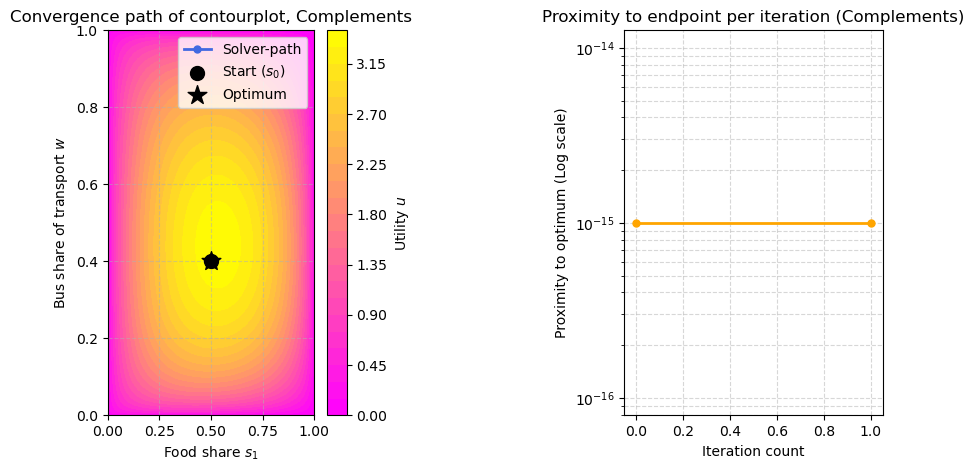

Processing convergence path for: SUBSTITUTES, sigma_B = 3.0


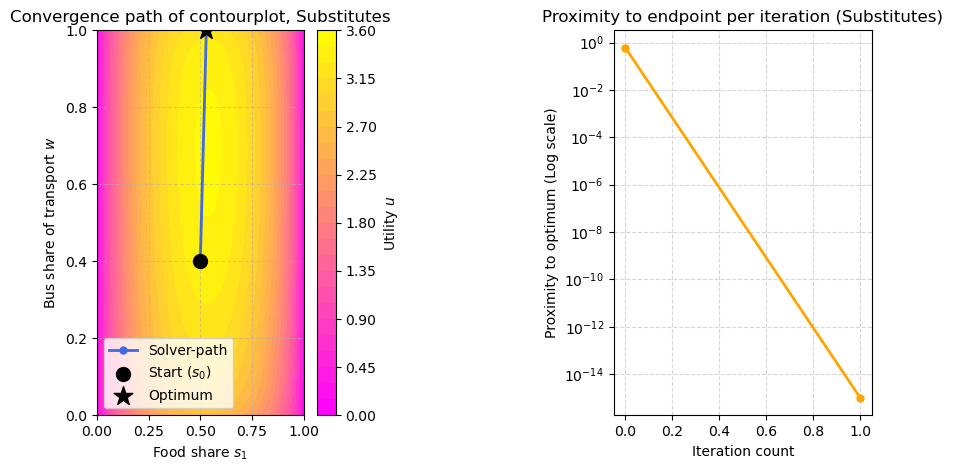

In [ ]:
# Setup for convergence path and plotting
if __name__ == '__main__':
    # Parameters
    I, p1, p2, p3 = 10.0, 1.0, 1.0, 1.5
    alpha, beta, sigma_A = 0.6, 0.5, 0.8

    calibrations = [('Complements', 0.4), ('Substitutes', 3.0)]

    for name, sigma_B in calibrations:
        print(f'Processing convergence path for: {name.upper()}, sigma_B = {sigma_B}')

        convergence_path = []

        res_sol = solve(p1, p2, p3, I, alpha, beta, sigma_A, sigma_B, path_list=convergence_path)

        if len(convergence_path) == 0:
            s0_w = p2 / (p2 + p3)
            convergence_path.append([0.5, s0_w])

            if res_sol['success']:
                convergence_path.append([res_sol['s1'], res_sol['w']])

        path_array = np.array(convergence_path)

        res_grid = grid_search(p1, p2, p3, I, alpha, beta, sigma_A, sigma_B, N=200)

        # Figure
        fig_conv = plt.figure(figsize=(10, 5))

        ax_conv = fig_conv.add_subplot(1, 2, 1)
        contour = ax_conv.contourf(res_grid['s1_grid'], res_grid['w_grid'], res_grid['u_grid'], levels=25, cmap='spring')
        fig_conv.colorbar(contour, ax=ax_conv, label='Utility $u$')

        if path_array.ndim > 1 and len(path_array) > 1:
            ax_conv.plot(path_array[:, 0], path_array[:, 1], '-o', color='royalblue', linewidth=2, markersize=5, label='Solver-path')
            ax_conv.scatter(path_array[0, 0], path_array[0, 1], color='black', marker='o', s=100, label='Start ($s_0$)', zorder=5)
        else:
            ax_conv.plot(path_array[0, 0], path_array[0, 1], 'o', color='royalblue', label='Start/Solver-path')
            ax_conv.scatter(path_array[0, 0], path_array[0, 1], color='black', marker='o', s=100, label='Start ($s_0$)', zorder=5)
        
        ax_conv.scatter(res_sol['s1'], res_sol['w'], color='black', marker='*', s=200, edgecolor='black', label='Optimum', zorder=5)
        
        ax_conv.set_title(f'Convergence path of contourplot, {name}')
        ax_conv.set_xlabel('Food share $s_1$')
        ax_conv.set_ylabel('Bus share of transport $w$')
        ax_conv.grid(True, linestyle='--', alpha=0.5)
        ax_conv.legend()

        ax_conv2 = fig_conv.add_subplot(1, 2, 2)
        
        final_pt = np.array([res_sol['s1'], res_sol['w']])
        distances = np.sqrt(np.sum((path_array - final_pt)**2, axis=1))
        iterations = np.arange(len(distances))
        distances = np.clip(distances, 1e-15, None)

        ax_conv2.plot(iterations, distances, '-o', color='orange', linewidth=2, markersize=5)
        ax_conv2.set_yscale('log')
        
        ax_conv2.set_title(f'Proximity to endpoint per iteration ({name})')
        ax_conv2.set_xlabel('Iteration count')
        ax_conv2.set_ylabel('Proximity to optimum (Log scale)')
        ax_conv2.grid(True, which="both", linestyle='--', alpha=0.5)

        plt.subplots_adjust(wspace=1)
        plt.show()

In [220]:
# Differing starting points and false success flag, setup
if __name__ == '__main__':
    I, p1, p2, p3 = 10.0, 1.0, 1.0, 1.5
    alpha, beta, sigma_A = 0.6, 0.5, 0.8
    eps = 1e-6

    # Six start points
    start_points = {
        'Middel (1/2, 1/2)        ': [0.5, 0.5],
        'Corner lower left (0, 0) ': [eps, eps],
        'Corner upper left (0, 1) ': [eps, 1.0 - eps],
        'Corner lower right (1, 0)': [1.0 - eps, eps],
        'Corner upper right (1, 1)': [1.0 - eps, 1.0 - eps],
        'Inner point              ': [0.25, 0.75]
    }

    for sigma_B in [0.4, 3.0]:
        name = 'Complements' if sigma_B == 0.4 else 'Substitutes'
        print(f"Testing start points for: {name.upper()} (sigma_B = {sigma_B})")
        print(f"{'Start point':<20}          | {'Status':<10}| {'Evaluations':<13} | {'s1':<8} | {'w':<8} | {'Utility u':<8}")
        print('-'*100)
        
        for label, s0 in start_points.items():
            # Direct counting of iterations
            def prep_mini(shares):
                s1, w = shares
                s2, s3 = (1.0 - s1) * w, (1.0 - s1) * (1.0 - w)
                x1, x2, x3 = (s1 * I) / p1, (s2 * I) / p2, (s3 * I) / p3
                x1, x2, x3 = np.clip(x1, 1e-7, None), np.clip(x2, 1e-10, None), np.clip(x3, 1e-7, None)
                rA, rB = 1.0 - (1.0 / sigma_A), 1.0 - (1.0 / sigma_B)
                tB = np.clip(beta * (x2**rB) + (1.0 - beta) * (x3**rB), 1e-7, None)
                xB = np.clip(tB**(1.0/rB), 1e-7, None)
                tA = np.clip(alpha * (x1**rA) + (1.0 - alpha) * (xB**rA), 1e-7, None)
                return -(tA**(1.0/rA))

            res = optimize.minimize(prep_mini, s0, method='L-BFGS-B', bounds=((1e-7, 1-1e-7), (1e-7, 1-1e-7)))
            status = "Success" if res.success else "Failed"
            
            print(f"{label:<20}     | {status:<10}| {res.nfev:<13} | {res.x[0]:<8.4f} | {res.x[1]:<8.4f} | {-res.fun:<8.4f}")
            
        print('')


Testing start points for: COMPLEMENTS (sigma_B = 0.4)
Start point                   | Status    | Evaluations   | s1       | w        | Utility u
----------------------------------------------------------------------------------------------------
Middel (1/2, 1/2)             | Success   | 18            | 0.5356   | 0.4395   | 3.4017  
Corner lower left (0, 0)      | Success   | 24            | 0.5356   | 0.4395   | 3.4017  
Corner upper left (0, 1)      | Success   | 30            | 0.5356   | 0.4395   | 3.4017  
Corner lower right (1, 0)     | Success   | 3             | 1.0000   | 0.0000   | 0.0000  
Corner upper right (1, 1)     | Success   | 12            | 0.9994   | 1.0000   | 0.0000  
Inner point                   | Success   | 24            | 0.5356   | 0.4395   | 3.4017  

Testing start points for: SUBSTITUTES (sigma_B = 3.0)
Start point                   | Status    | Evaluations   | s1       | w        | Utility u
------------------------------------------------------------

<p>As shown above, the false success flag happens when when the calibration for<br>
sigma_B is 0.4 (and therefore the products are complements), when in the upper<br>
and lower right corners. 
</p>
<p>Because of the tolerance hindering division by 0 <br>
the transport share gets locked in place, which causes a change in w to not<br>
affect the total utility, this yields a gradient of 0.0. Due to this, <br>
the optimizer already reads this as having reached the optimum, and reports<br>
the false success = True flag, despite a utility at 0.0.
</p>

In [230]:
# Inserting prep_minimize again:
def prep_minimize(shares):
        s1, w = shares
        s2 = (1.0 - s1) * w
        s3 = (.0 - s1) * (1.0 - w)

        x1 = (s1 * I) / p1
        x2 = (s2 * I) / p2
        x3 = (s3 * I) / p3

        x1 = np.clip(x1, 1e-7, None)
        x2 = np.clip(x2, 1e-7, None)
        x3 = np.clip(x3, 1e-7, None)

        rho_A = 1.0 - (1.0 / sigma_A)
        rho_B = 1.0 - (1.0 / sigma_B)

        term_B = beta * (x2 ** rho_B) + (1.0 - beta) * (x3 ** rho_B)
        term_B = np.clip(term_B, 1e-7, None)

        xB = term_B ** (1.0 / rho_B)
        xB = np.clip(xB, 1e-7, None)

        term_A = alpha * (x1 ** rho_A) + (1.0 - alpha) * (xB ** rho_A)
        term_A = np.clip(term_A, 1e-7, None)

        u = term_A ** (1.0 / rho_A)

        return -u

# Varying given settings
if __name__ == '__main__':
    I, p1, p2, p3 = 10.0, 1.0, 1.0, 1.5
    alpha, beta, sigma_A = 0.6, 0.5, 0.8
    s1_0 = 0.5
    w_0 = p2 / (p2 + p3)
    s0 = [s1_0, w_0]
    bounds = ((1e-5, 1.0 - 1e-5), (1e-5, 1.0 - 1e-5))

    ftol_vals = [10 ** (-4), 10 ** (-8), 10 ** (-12), 10 ** (-16)] # Stop when the agenda stops changing
    gtol_vals = [10 ** (-2), 10 ** (-5), 10 ** (-8), 10 ** (-12)] # Stop when the gradient is very small

    for sigma_B in [0.4, 3.0]:
        name = 'Complements' if sigma_B == 0.4 else 'Substitutes'
        print(f"Tolerance analysis for: {name.upper()} (sigma_B = {sigma_B})")
        print(f"{'Option':<10} | {'Tolerance':<8}| {'s1':<8} | {'w':<8} | {'Utility u':<10} | {'Iterations/evaluations':<5}")
        print("-" * 100)
        
        # Test ftol
        for tol in ftol_vals:
            res = optimize.minimize(prep_minimize, s0, method='L-BFGS-B', bounds=bounds, options={'ftol': tol})
            print(f"{'ftol':<10} | {tol:<8} | {res.x[0]:<8.4f} | {res.x[1]:<8.4f} | {-res.fun:<10.5f} | {res.nfev:<5}")
            
        # Test gtol
        for tol in gtol_vals:
            res = optimize.minimize(prep_minimize, s0, method='L-BFGS-B', bounds=bounds, options={'gtol': tol})
            print(f"{'gtol':<10} | {tol:<8} | {res.x[0]:<8.4f} | {res.x[1]:<8.4f} | {-res.fun:<10.5f} | {res.nfev:<5}")

        print('')


Tolerance analysis for: COMPLEMENTS (sigma_B = 0.4)
Option     | Tolerance| s1       | w        | Utility u  | Iterations/evaluations
----------------------------------------------------------------------------------------------------
ftol       | 0.0001   | 0.5000   | 0.4000   | 0.00001    | 3    
ftol       | 1e-08    | 0.5000   | 0.4000   | 0.00001    | 3    
ftol       | 1e-12    | 0.5000   | 0.4000   | 0.00001    | 3    
ftol       | 1e-16    | 0.5000   | 0.4000   | 0.00001    | 3    
gtol       | 0.01     | 0.5000   | 0.4000   | 0.00001    | 3    
gtol       | 1e-05    | 0.5000   | 0.4000   | 0.00001    | 3    
gtol       | 1e-08    | 0.5000   | 0.4000   | 0.00001    | 6    
gtol       | 1e-12    | 0.5000   | 0.4000   | 0.00001    | 6    

Tolerance analysis for: SUBSTITUTES (sigma_B = 3.0)
Option     | Tolerance| s1       | w        | Utility u  | Iterations/evaluations
----------------------------------------------------------------------------------------------------
ftol     

<p>It seems that at around a tolerance smaller than 1e-4 or 1e-5, the results don't<br>
change to a significant degree. This goes for both ftol and gtol. An explanation<br>
for this could be that it results in already being very close to the optimum, and<br>
there simply isn't any other point that could yield a misleading maximum utility<br>
in the proxmity.
</p>

> Part 3: Relative prices and demand

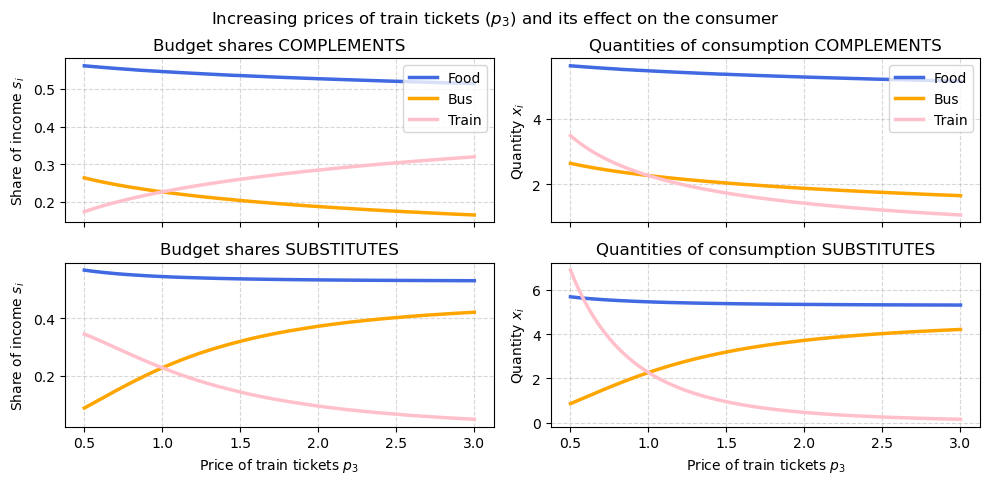

In [240]:
def analyze_p3_inc(p1, p2, I, alpha, beta, sigma_A, calibrations, N_points=100):
    """
    Solves model for a grid of p3 prices and plots budget shares
    and product amounts for the two calibrations of sigma_B in the same figure.
    """
    p3_grid = np.linspace(0.5, 3.0, N_points)

    results_plot = {name: {
        's1': [], 's2': [], 's3': [],
        'x1': [], 'x2': [], 'x3': []} for name, _ in calibrations}

    for name, sigma_B in calibrations:
        for p3_val in p3_grid:
            
            # Vi indlejrer prep_minimize her, så den dynamisk bruger p3_val fra loopet
            def prep_minimize(shares):
                s1, w = shares
                s2 = (1.0 - s1) * w
                s3 = (1.0 - s1) * (1.0 - w)

                x1 = (s1 * I) / p1
                x2 = (s2 * I) / p2
                x3 = (s3 * I) / p3_val  # Bruger den dynamiske pris fra loopet

                x1 = np.clip(x1, 1e-7, None)
                x2 = np.clip(x2, 1e-7, None)
                x3 = np.clip(x3, 1e-7, None)

                rho_A = 1.0 - (1.0 / sigma_A)
                rho_B = 1.0 - (1.0 / sigma_B)

                term_B = beta * (x2 ** rho_B) + (1.0 - beta) * (x3 ** rho_B)
                term_B = np.clip(term_B, 1e-7, None)

                xB = term_B ** (1.0 / rho_B)
                xB = np.clip(xB, 1e-7, None)

                term_A = alpha * (x1 ** rho_A) + (1.0 - alpha) * (xB ** rho_A)
                term_A = np.clip(term_A, 1e-7, None)

                u = term_A ** (1.0 / rho_A)
                return -u

            # Initial guess
            s0 = [0.5, p2 / (p2 + p3_val)]
            bounds = ((1e-5, 1.0 - 1e-5), (1e-5, 1.0 - 1e-5))
            
            res = optimize.minimize(prep_minimize, s0, method='SLSQP', bounds=bounds)
            
            if res.success:
                s1_opt = float(res.x[0])
                w_opt = float(res.x[1])
                
                s2_opt = (1.0 - s1_opt) * w_opt
                s3_opt = (1.0 - s1_opt) * (1.0 - w_opt)
                
                results_plot[name]['s1'].append(s1_opt)
                results_plot[name]['s2'].append(s2_opt)
                results_plot[name]['s3'].append(s3_opt)
                
                results_plot[name]['x1'].append((s1_opt * I) / p1)
                results_plot[name]['x2'].append((s2_opt * I) / p2)
                results_plot[name]['x3'].append((s3_opt * I) / p3_val)
            else:
                # In case of failure
                for key in ['s1', 's2', 's3', 'x1', 'x2', 'x3']:
                    results_plot[name][key].append(np.nan)

    # Plotting figure
    fig_p3, axes_p3 = plt.subplots(2, 2, figsize=(10, 5), sharex=True)
    
    goods_labels = ['Food', 'Bus', 'Train']
    colors = ['royalblue', 'orange', 'pink']

    for i, (name, _) in enumerate(calibrations):
        data = results_plot[name]

        # Left column: Budget shares s
        ax_s = axes_p3[i, 0]
        ax_s.plot(p3_grid, data['s1'], label=goods_labels[0], color=colors[0], linewidth=2.5)
        ax_s.plot(p3_grid, data['s2'], label=goods_labels[1], color=colors[1], linewidth=2.5)
        ax_s.plot(p3_grid, data['s3'], label=goods_labels[2], color=colors[2], linewidth=2.5)
        
        ax_s.set_title(f'Budget shares {name.upper()}')
        ax_s.set_ylabel('Share of income $s_i$')
        ax_s.grid(True, linestyle='--', alpha=0.5)
        if i == 0:
            ax_s.legend(loc='upper right')

        # Right column: Quantities of consumption x
        ax_x = axes_p3[i, 1]
        ax_x.plot(p3_grid, data['x1'], label=goods_labels[0], color=colors[0], linewidth=2.5)
        ax_x.plot(p3_grid, data['x2'], label=goods_labels[1], color=colors[1], linewidth=2.5)
        ax_x.plot(p3_grid, data['x3'], label=goods_labels[2], color=colors[2], linewidth=2.5)
        
        ax_x.set_title(f'Quantities of consumption {name.upper()}')
        ax_x.set_ylabel('Quantity $x_i$')
        ax_x.grid(True, linestyle='--', alpha=0.5)
        if i == 0:
            ax_x.legend(loc='upper right')

    axes_p3[1, 0].set_xlabel('Price of train tickets $p_3$')
    axes_p3[1, 1].set_xlabel('Price of train tickets $p_3$')
    
    plt.suptitle('Increasing prices of train tickets ($p_3$) and its effect on the consumer', y=0.96)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    I_val, p1_val, p2_val = 10.0, 1.0, 1.0
    alpha_val, beta_val, sigma_A_val = 0.6, 0.5, 0.8
    calibrations_list = [('Complements', 0.4), ('Substitutes', 3.0)]
    
    analyze_p3_inc(p1_val, p2_val, I_val, alpha_val, beta_val, sigma_A_val, calibrations_list)

<p>When the bus and train are complements, and increase in the price of the<br>
train tickets results in a rising budget share of the train. This is because<br>
the two goods being complements means that the consumer wants these in pairs,<br>
so a price increase in one means an overall increase in the pairing, so the<br>
quantities fall, but since p3 is still increasing, its share increases.
</p>
<p>When the two goods are substitutes, an increase in the train ticket prices<br>
means that the bus at some point (all things equal) will be cheaper relative<br>
to the train tickets, and the consumer will substitute the two for the cheaper<br>
option.
</p>
<p>Since the train tickets are increasingly expensive, and this changes the<br>
demand for food, it suggests that food and transport are complements to<br>
a lesser extent: The consumer, in both calibrations, will only decrease<br>
the consumption of food slightly, because the pairing of food and transport<br>
has become more expensive. Similarly to the first calibration mentioned above.
</p>

> Part 4: Lump-sum taxes and product taxes

In [262]:
class GovernmentClass:
    """
    Government raising tax revenue from a consumer
    """
    def __init__(self, par=None):
        # Integreret setup direkte fra dit ConsumerClass kodestykke
        self.setup()
        self.setup_government()

        if not par is None:
            for k, v in par.items():
                self.par.__dict__[k] = v

        self.sync_pre_tax()

    def setup(self):
        par = self.par = SimpleNamespace()
        self.sol = SimpleNamespace()

        par.alpha = 0.6
        par.beta = 0.5

        par.sigma_A = 0.8
        par.sigma_B = 0.4

        par.p1 = 1.0
        par.p2 = 1.0
        par.p3 = 1.5
        par.I = 10.0

        par.s_min = 1e-12

    def setup_government(self):
        """ add the taxes to the parameters """
        par = self.par
        par.T = 0.0      # lump-sum
        par.tau1 = 0.0   # Tax rate on food
        par.tau2 = 0.0   # Tax rate on bus trips
        par.tau3 = 0.0   # Tax rate on train trips

    def sync_pre_tax(self):
        par = self.par
        par.p1_pre = par.p1
        par.p2_pre = par.p2
        par.p3_pre = par.p3
        par.I_pre = par.I

    def __str__(self):
        par = self.par
        lines = ['GovernmentClass']
        lines.append(f'alpha = {par.alpha:.2f}, beta = {par.beta:.2f}')
        lines.append(f'sigma_A = {par.sigma_A:.2f}, sigma_B = {par.sigma_B:.2f}')
        lines.append(f'p1_pre = {par.p1_pre:.2f}, p2_pre = {par.p2_pre:.2f}, p3_pre = {par.p3_pre:.2f}')
        lines.append(f'I_pre = {par.I_pre:.2f}')
        return '\n'.join(lines)

    def solve(self, method='SLSQP'):
        p = self.par
        sol = self.sol

        res = solve_consumer_problem(p.p1, p.p2, p.p3, p.I, p.alpha, p.beta, p.sigma_A, p.sigma_B, method=method)
        sol.success = res['success']
        if sol.success:
            sol.s1 = float(res['optimal_s1'])
            sol.w = float(res['optimal_w'])
            sol.s2 = float(res['budget_shares'][1])
            sol.s3 = float(res['budget_shares'][2])
            sol.x1 = float(res['quantities'][0])
            sol.x2 = float(res['quantities'][1])
            sol.x3 = float(res['quantities'][2])
            sol.u = float(res['max_utility'])
        return res

    def set_taxes(self, T=0.0, tau1=0.0, tau2=0.0, tau3=0.0):
        par = self.par

        par.T = T
        par.tau1 = tau1
        par.tau2 = tau2
        par.tau3 = tau3

        par.p1 = (1 + tau1) * par.p1_pre
        par.p2 = (1 + tau2) * par.p2_pre
        par.p3 = (1 + tau3) * par.p3_pre

        par.I = par.I_pre - T

    # Implementing tax revenue
    def tax_rev(self, opt=None):
        par = self.par

        if opt is None:
            self.solve()
            x1 = self.sol.x1
            x2 = self.sol.x2
            x3 = self.sol.x3
        else:
            x1 = opt.x1
            x2 = opt.x2
            x3 = opt.x3

        # Lump-sum and product tax (sum = revenue R)
        R = par.T + (
                par.tau1 * par.p1_pre * x1 +
                par.tau2 * par.p2_pre * x2 +
                par.tau3 * par.p3_pre * x3
            )

        return R
    # Setup
    def revenue_and_utility(self, tau, goods=(2,)):
        t1 = tau if 1 in goods else 0.0
        t2 = tau if 2 in goods else 0.0
        t3 = tau if 3 in goods else 0.0
        
        self.set_taxes(T=0.0, tau1=t1, tau2=t2, tau3=t3)
        self.solve()
        
        R = self.tax_rev()
        u = self.sol.u if self.sol.success else np.nan
        return R, u

    # Train and bus only tax rates when these are complements have a peak. The rest keep rising.
    def max_revenue(self, goods=(3,), tau_max=3.0, N=1001):
        """
        The most revenue a given tax instrument can raise
        """
        tau_grid = np.linspace(0.0, tau_max, N)
        best_R = -1.0
        best_tau = 0.0
            
        for tau in tau_grid:
            R, _ = self.revenue_and_utility(tau, goods=goods)
            
            if R > best_R:
                best_R = R
                best_tau = tau
                    
        return best_tau, best_R
    
    def revenue_and_utility_lump_sum(self, T):
        """ 
        Calculates revenue and utility for a lump-sum tax of T 
        """
        self.set_taxes(T=T, tau1=0.0, tau2=0.0, tau3=0.0)
        self.solve()
        
        R = self.tax_rev()
        u = self.sol.u if self.sol.success else np.nan
        return R, u

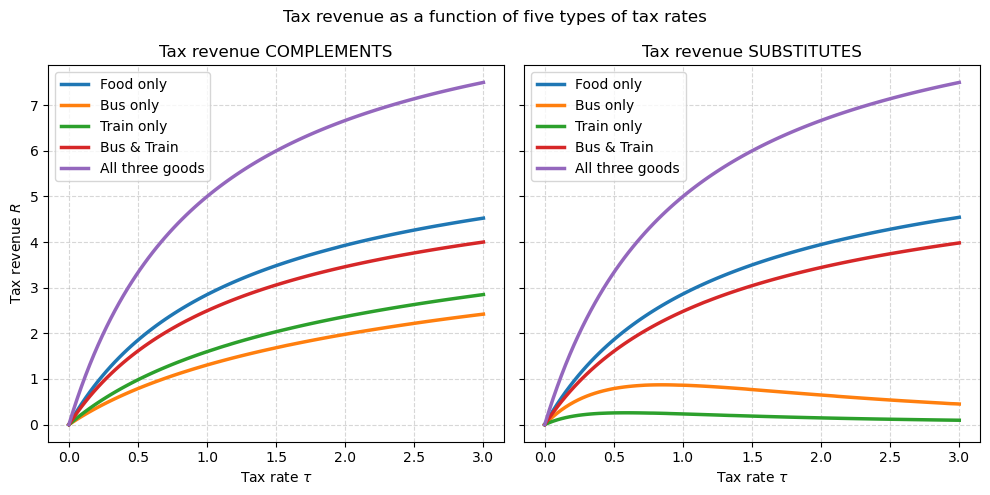

In [258]:
# Five taxes and plotting
if __name__ == '__main__':
    tau_grid = np.linspace(0.0, 3.0, 100)
    
    # Five taxes
    tax_scenarios = [
        ("Food only", (1,)),
        ("Bus only", (2,)),
        ("Train only", (3,)),
        ("Bus & Train", (2, 3)),
        ("All three goods", (1, 2, 3))
    ]
    
    calibrations = [('Complements', 0.4), ('Substitutes', 3.0)]
    
    # Plotting
    fig_t, axes_t = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
    
    for index, (name, sigma_B) in enumerate(calibrations):
        ax_t = axes_t[index]
        gov = GovernmentClass(par={'sigma_B': sigma_B})
        
        for label, goods in tax_scenarios:
            revenues = []
            for tau in tau_grid:
                R, _ = gov.revenue_and_utility(tau, goods=goods)
                revenues.append(R)
            
            ax_t.plot(tau_grid, revenues, label=label, linewidth=2.5)
            
        ax_t.set_title(f'Tax revenue {name.upper()}')
        ax_t.set_xlabel('Tax rate $\\tau$')
        if index == 0:
            ax_t.set_ylabel('Tax revenue $R$')
        ax_t.grid(True, linestyle='--', alpha=0.5)
        ax_t.legend(loc='upper left')

    plt.suptitle('Tax revenue as a function of five types of tax rates', y=0.98)
    plt.tight_layout()
    plt.show()

In [257]:
# Calculating the max revenue from train tickets
if __name__ == '__main__':
    I_val, p1_val, p2_val = 10.0, 1.0, 1.0
    alpha_val, beta_val, sigma_A_val = 0.6, 0.5, 0.8
    
    gov_substitutes = GovernmentClass(par={'sigma_B': 3.0})
    
    opt_tau, max_rev = gov_substitutes.max_revenue(goods=(3,), tau_max=3.0, N=1001)
    
    print("Max revenue gained from train tickets tax only (substitutes)")
    print(f"Optimal tax rate tau_3  : {opt_tau*100:.2f}%")
    print(f"Max revenue R_max   : {max_rev:.4f}")

Max revenue gained from train tickets tax only (substitutes)
Optimal tax rate tau_3  : 59.10%
Max revenue R_max   : 0.2589


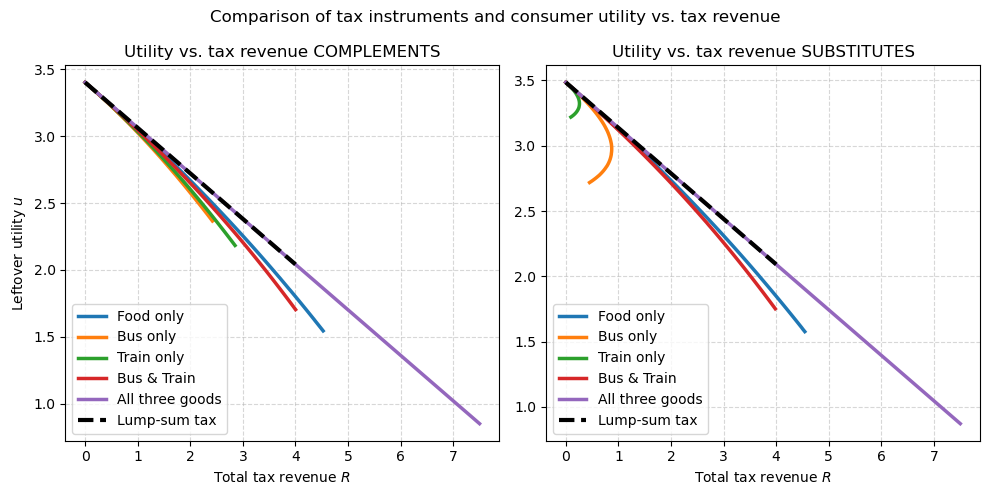

In [264]:
# Plotting utility against revenue raised for the five taxes and the lump-sum tax
if __name__ == '__main__':
    tau_grid = np.linspace(0.0, 3.0, 100)
    T_grid = np.linspace(0.0, 4.0, 100)  # Lump-sum
    
    tax_scenarios = [
        ("Food only", (1,)),
        ("Bus only", (2,)),
        ("Train only", (3,)),
        ("Bus & Train", (2, 3)),
        ("All three goods", (1, 2, 3))
    ]
    
    calibrations = [('Complements', 0.4), ('Substitutes', 3.0)]
    
    # Plotting with one panel per calibration
    fig_comp, axes_comp = plt.subplots(1, 2, figsize=(10, 5)) # comp for comparison
    
    for index, (name, sigma_B) in enumerate(calibrations):
        ax_comp = axes_comp[index]
        gov = GovernmentClass(par={'sigma_B': sigma_B})
        
        # Five product taxes
        for label, goods in tax_scenarios:
            R_list, u_list = [], []
            for tau in tau_grid:
                R, u = gov.revenue_and_utility(tau, goods=goods)
                R_list.append(R)
                u_list.append(u)
            ax_comp.plot(R_list, u_list, label=label, linewidth=2.5)
            
        # Lump-sum tax
        R_lump, u_lump = [], []
        for T in T_grid:
            R, u = gov.revenue_and_utility_lump_sum(T)
            R_lump.append(R)
            u_lump.append(u)
        ax_comp.plot(R_lump, u_lump, label="Lump-sum tax", color="black", linestyle="--", linewidth=3)
        
        ax_comp.set_title(f'Utility vs. tax revenue {name.upper()}')
        ax_comp.set_xlabel('Total tax revenue $R$')
        if index == 0:
            ax_comp.set_ylabel('Leftover utility $u$')
        ax_comp.grid(True, linestyle='--', alpha=0.5)
        ax_comp.legend(loc='lower left')

    plt.suptitle('Comparison of tax instruments and consumer utility vs. tax revenue', y=0.98)
    plt.tight_layout()
    plt.show()

<p>In both scenarios is the lump-sum tax the 'cheapest' way to raise revenue<br>
from tax, because it has an effect on the overall income rather than the<br>
price relations between the three goods. So the utility won't be skewed.
</p>
<p>After the lump-sum tax, the equal rate of all three goods is the second<br>
best, due to a similarly non-skewing effect on the price relations and<br>
therein the utility.
</p>
<p>Between the substitutes and complements side, only the bus only and<br>
train only switch places in terms of 'cheapness rankings'. However, in<br>
the case of these two being substitutes, there is once again a peak in<br>
tax revenue gained. Thereafter the tax revenue decreases again.
</p>

In [265]:
# 5. Let the government need R = 0.20, i.e. 2 percent of income. Use a root-finder
#to find the tax rate that raises exactly that for each instrument, and report the
#rate and the resulting utility in one table per calibration. Rank the instruments,
#and comment in particular on the tax on train tickets.
#Hint: optimize.root_scalar(f,bracket=[...],method=’brentq’) where f is
#the revenue minus the target.

> Part 5: Extension

In [ ]:
# Extend the model in one direction of your own choice, solve it, and describe the
#results.
#Note: This is intended as an open question, and we encourage you to be creative.